In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.collections import PolyCollection

In [2]:
import re
import pandas as pd

def extract_latency(file_path, label):
    values = []
    reading_values = False

    with open(file_path, "r") as file:
        for line in file:
            line = line.strip()
            if line == "#Start#":
                reading_values = True
                continue
            if reading_values and line.isdigit():
                values.append(int(line))

    values_in_ms = [v / 1000 for v in values]

    return pd.DataFrame({
        'Latency (ms)': values_in_ms,
        'Added Latency Range (in Milliseconds)': label
    })


df_top_left = extract_latency("./messwerte_links_oben.txt", "links oben")
df_bottom_right = extract_latency("./messwerte_rechts_unten.txt", "rechts unten")

In [3]:
df = pd.concat([df_top_left, df_bottom_right], ignore_index=True)
df

,Latency (ms),Added Latency Range (in Milliseconds)
0,12.328,links oben
1,13.440,links oben
2,15.244,links oben
3,12.328,links oben
4,13.340,links oben
...,...,...
181,17.940,rechts unten
182,16.804,rechts unten
183,17.592,rechts unten
184,18.152,rechts unten


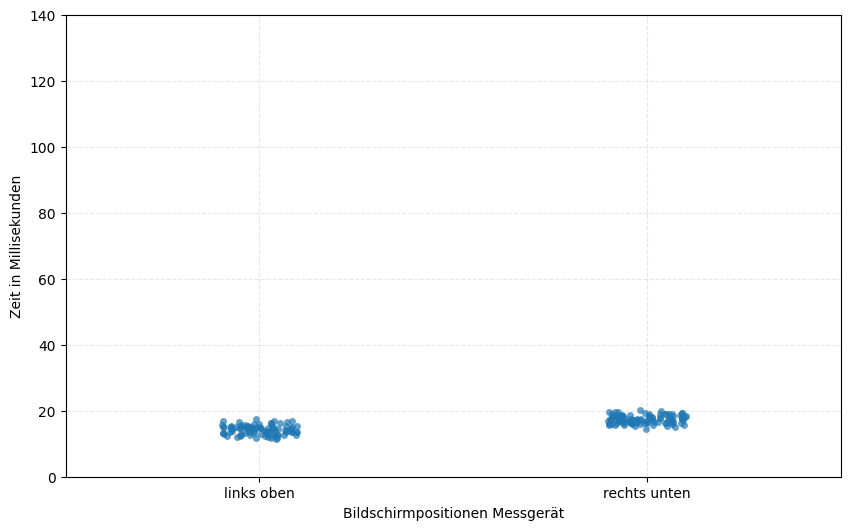

In [4]:
plt.figure(figsize=(10, 6))

sns.stripplot(x=df['Added Latency Range (in Milliseconds)'], y=df['Latency (ms)'], alpha=0.7, jitter=True)

plt.xlabel("Bildschirmpositionen Messgerät")
plt.ylabel("Zeit in Millisekunden")
plt.grid(True, linestyle='--', alpha=0.3)

plt.ylim([0, 140])

plt.show()

In [5]:
df_top_left["Latency (ms)"].mean()

np.float64(14.252137931034483)

In [6]:
df_bottom_right["Latency (ms)"].mean()

np.float64(17.379111111111115)

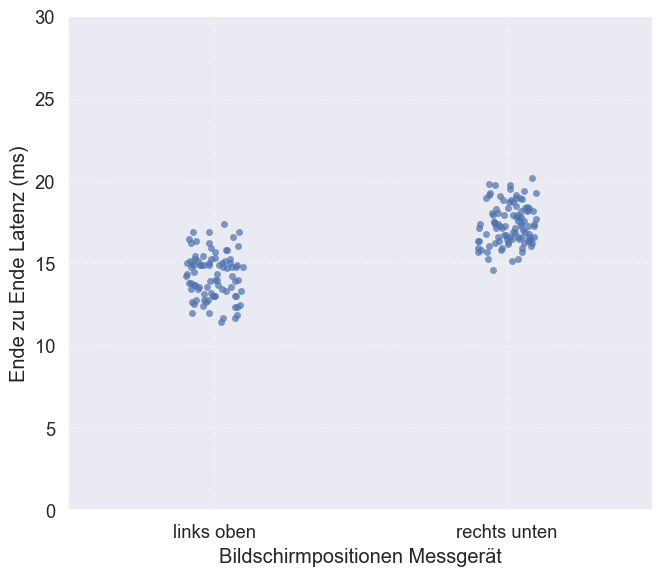

In [7]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10, 6))

gs = gridspec.GridSpec(1, 2, width_ratios=[3, 6]) 

sns.set_style("whitegrid")
sns.set(font_scale = 1.2)

ax0 = plt.subplot(gs[1])
sns.stripplot(ax=ax0, x=df['Added Latency Range (in Milliseconds)'], y=df['Latency (ms)'], alpha=0.7, jitter=True)
ax0.set_xlabel("Bildschirmpositionen Messgerät")
ax0.set_ylabel("Ende zu Ende Latenz (ms)")
ax0.grid(True, linestyle='--', alpha=0.3)
ax0.set_ylim([0, 30])

plt.tight_layout()
plt.show()

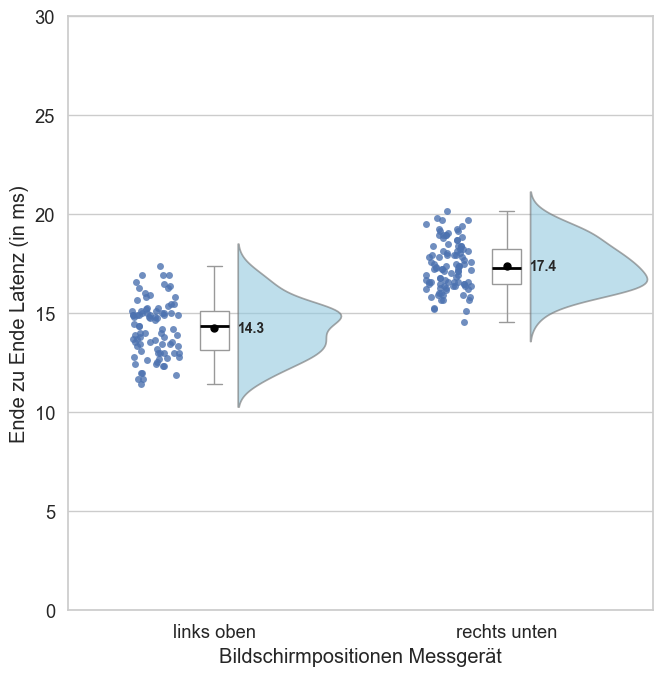

In [18]:
fig = plt.figure(figsize=(10, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 6]) 

sns.set_style("whitegrid")
ax0 = plt.subplot(gs[1])

x_data = df['Added Latency Range (in Milliseconds)']
y_data = df['Latency (ms)']
sns.violinplot(ax=ax0, x=x_data, y=y_data, inner=None, color="skyblue", alpha=0.6)

for art in ax0.findobj(PolyCollection):
    for path in art.get_paths():
        center = np.mean(path.vertices[:, 0])
        path.vertices[:, 0] = np.maximum(path.vertices[:, 0], center) + 0.08

sns.stripplot(ax=ax0, x=x_data, y=y_data, alpha=0.8, size=5, jitter=0.08, zorder=1)

offset_left = -0.2
for artist in ax0.collections:
    if not isinstance(artist, PolyCollection):
        offsets = artist.get_offsets()
        offsets[:, 0] = offsets[:, 0] + offset_left
        artist.set_offsets(offsets)

sns.boxplot(ax=ax0, x=x_data, y=y_data, 
            width=0.1, color="white", 
            showfliers=False, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"black", "markeredgecolor":"black", "markersize":"5"},
            medianprops={'color': 'black', 'linewidth': 2},
            zorder=10)

means = df.groupby('Added Latency Range (in Milliseconds)')['Latency (ms)'].mean()
for i, m_val in enumerate(means):
    ax0.text(i + 0.08, m_val, f"{m_val:.1f}", 
             fontsize=10, fontweight='bold', verticalalignment='center')

ax0.set_xlabel("Bildschirmpositionen Messgerät")
ax0.set_ylabel("Ende zu Ende Latenz (in ms)")
ax0.set_ylim([0, 30])

plt.tight_layout()
plt.show()